<div style="border: 2px solid #FFB74D; background-color: #FFF3E0; border-radius: 8px; padding: 10px; font-family: Arial, sans-serif; color: #333; box-shadow: 2px 2px 8px rgba(0, 0, 0, 0.1); max-width: 750px; margin: 0 auto;">
  <strong style="color: #E65100;">⚠️ Note:</strong> This notebook uses MCMC samplers from the new <code>cuqi.experimental.mcmc</code> module, which are expected to become the default soon. Check out the <a href="https://cuqi-dtu.github.io/CUQIpy/api/_autosummary/cuqi.experimental.mcmc.html#module-cuqi.experimental.mcmc">documentation</a> for more details.
</div>

## <font color=#CD853F> 1. Defining the BIP </font> <a class="anchor" id="r-defining-the-bip"></a>


Consider the following inverse problem: given observed data $b$, determine $x_1$, and $x_2$:

$$\mathbf{y_{obs}} = x_1^2/2 + 3x_2^2 + n \;\;\mathrm{with}\;\; n \sim \mathcal{N}(0, \texttt{sigma2}) \ ,$$

with $\texttt{sigma2}=0.1$

We can also write it in the following matrix form:

$$\mathbf{y_{obs}} = \mathbf{A}(\mathbf{x}) + n \ , $$

with $\mathbf{A}: \mathbb{R}^2 \rightarrow \mathbb{R}, x = (x_1, x_2) \mapsto
x_1^2/2 + 3x_2^2$. Its gradient $\nabla_{\mathbf{A}}$ at point $\mathbf{x}$ is given by

$$
\nabla {\mathbf{A}}(\mathbf{x}) = [x_1, 6 x_2]
$$

This problem is:
* Considered a non-linear inverse problem since the forward model is non-linear.
* Ill-posed (in the sense of Hadamard [1]) since the solution is not unique, i.e., for some given value of $y$, e.g., $y=4$, all parameter pairs $(x_1, x_2)$ satisfying $x_1^2/2 + 3x_2^2 = 4$ are solutions to the (noise-free) problem.

# Principles behind MYULA
The goal is to solve this inverse problem by sampling from the posterior
distribution given by $\pi(x|y) \propto \pi(x) \pi(y|x)$.

We assume a Gaussian likelihood, ie $- \log \pi(y|x) = \|Ax-y \|_2^2/2 \sigma^2$
and a prior such that $- \log \pi (x) =  g(x)$ with $g$ convex.

To sample from $\pi(x|y)$, we are going to apply a ULA based algorithm,
MYULA (https://arxiv.org/pdf/1612.07471).
We recall that ULA

$$x_{k+1} = x_k + \delta \nabla \log \pi(x_k |y) + \sqrt{2 \delta} z_{k+1} \ ,$$

$$x_{k+1} = x_k + \delta \nabla \log \pi(y | x_k) + \delta \nabla \log \pi(x_k) + \sqrt{2 \delta} z_{k+1}$$

with $(z_k)_{k \in \mathbb{N}^*}$ a sequence of independent and
identically distributed Gaussian random variables
with zero mean and identity covariance.

In the case where $\log \pi(x)$ is not differentiable we can
unfortunately not apply ULA. The idea is to consider a surrogate
posterior density $\pi_{\alpha} (x|y) \propto \pi(y|x) \pi_{\alpha} (x)$
where

$\pi_{\alpha}(x) \propto \exp(- g_{\alpha} (x))$

and $g_{\alpha}$ is the
$\alpha$-Moreau envelope of $g$, ie


$$g_\alpha(x) = \operatorname{inf}_z \| x- z \|_2^2/2 \alpha + g(z) \ .$$

$g_\alpha$ is continuously differentiable with $1/\alpha$-Lipschitz gradient and s.t


$\nabla g_{\alpha} (x) = (x- \operatorname{prox}_g^{\alpha} (x))/\alpha$

 with
$$
\operatorname{prox}_g^{\alpha} (x) = \operatorname{argmin}_z \|x-z \|_2^2/2\alpha + g(z)$$
See https://link.springer.com/chapter/10.1007/978-3-319-48311-5_31 for more details.

MYULA consists in applying ULA to a smoothed target distribution. It reads

\begin{align*}
  x_{k+1} &= x_k + \delta \nabla \log \pi_{\alpha}(x_k |y) + \sqrt{2 \delta} z_{k+1}\\
  &= x_k + \delta \nabla \log \pi(y | x_k) + \delta \nabla \log \pi_{\alpha}(x_k) + \sqrt{2 \delta} z_{k+1}\\
  &= x_k + \delta \nabla \log \pi(y | x_k) - \delta (x_k - \operatorname{prox}_g^{\alpha} (x_k))/{\alpha} + \sqrt{2 \delta} z_{k+1}.
  \end{align*}

where $\alpha$ corresponds to the smoothing strength of $g$.

To illustrate MYULA, we will consider $g(x) = i_{\mathbb{R}+}(x)$.

In [23]:
# Importing the required libraries
from cuqi.distribution import Gaussian, Posterior
from cuqi.problem import BayesianProblem
from cuqi.model import Model
from cuqi.utilities import plot_1D_density, plot_2D_density
import numpy as np
import matplotlib.pyplot as plt
from cuqi.implicitprior import RestorationPrior, MoreauYoshidaPrior
from cuqi.experimental.mcmc import ULA, MYULA

### <font color=#8B4513> 1.1. Inverse problem </font> <a class="anchor" id="r-inverse-problem"></a>

Let us define the forward model $\mathbf{A}$.

In [24]:
def forward(x):
    return 0.5*x[0]**2 + 3*x[1]**2

def jacobian(x): # Can use "x" or "wrt" as the input argument name
    return np.array([[x[0], 6*x[1]]])

A = Model(forward, range_geometry=1, domain_geometry=2,jacobian=jacobian)

In the following cell we define the true signal $\mathbf{x}=[1, 1]$, the noise level
$\texttt{sigma2}=0.1$ and the observation $\mathbf{y}$.

In [25]:
# True signal
x = np.ones(2, dtype=float)
# Seed
np.random.seed(0)
# Noise
sigma2 = 0.1
sigma = np.sqrt(sigma2)
n = np.random.randn(1)
# Noiseless observation
Ax = A(x)
# Noisy observation
y_obs = A(x) + sigma*n

In [26]:
print("The observed signal is equal to ", y_obs[0])
print("The noiseless signal is equal to ", Ax)

The observed signal is equal to  4.0578423325021165
The noiseless signal is equal to  3.5


### <font color=#8B4513> 1.2. The likelihood </font> <a class="anchor" id="r-the-likelihood"></a>

We first specify the data distribution as follows:

In [27]:
y = Gaussian(mean=A, cov=sigma2)
print(y)

CUQI Gaussian. Conditioning variables ['x'].


Then we can specify the distribution as follows

In [28]:
likelihood = y(y=y_obs)
print(likelihood)

CUQI Gaussian Likelihood function. Parameters ['x'].


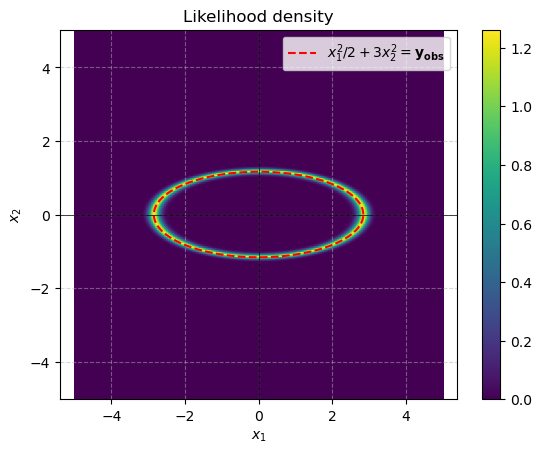

In [29]:
x1_lim = np.array([-5, 5])
x2_lim = np.array([-5, 5])
plot_2D_density(
    likelihood,
    v1_min=x1_lim[0], v1_max=x1_lim[1],
    v2_min=x2_lim[0], v2_max=x2_lim[1])
plt.colorbar()
plt.title("Likelihood density")

# Generate theta values
theta = np.linspace(0, 2 * np.pi, 100)

# Parameterize the ellipse
x1 = np.sqrt(y_obs*2) * np.cos(theta)
x2 = np.sqrt(y_obs / 3) * np.sin(theta)

# Plot the ellipse
plt.plot(x1, x2,  '--r', label=r'$x_1^2/2 + 3x_2^2 = \mathbf{y_{obs}}$')
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.axis('equal')  # Equal scaling for x and y axes
plt.show()

### <font color=#8B4513> 1.3. The RestorationPrior </font> <a class="anchor" id="r-the-Restoration-Prior"></a>

In [30]:
gamma = 1
alpha = 0.05*np.copy(sigma2) #0.05

#def denoiser(x, restoration_strength=None, strength_reg=None):
#    threshold = restoration_strength*strength_reg
#    return np.sign(x) * np.maximum(np.abs(x) - threshold, 0)
def denoiser(x, restoration_strength=None, strength_reg=None):
    return x*(x>0) + 0*(x<0)

print(denoiser(x, alpha, gamma))


[1. 1.]


In [31]:
restorator_kwargs = {}
restorator_kwargs["strength_reg"] = gamma

In [32]:
restorator = RestorationPrior(
    denoiser,
    restorator_kwargs=restorator_kwargs,
    geometry=likelihood.model.domain_geometry
)

In [33]:
myprior = MoreauYoshidaPrior(prior=restorator, smoothing_strength=alpha)
print(myprior)

CUQI MoreauYoshidaPrior.


In [34]:
smoothed_posterior=Posterior(likelihood, myprior)
print(smoothed_posterior)

Posterior(
    Equation:
	 p(myprior|y) ∝ L(myprior|y)p(myprior)
    Densities:
	y ~ CUQI Gaussian Likelihood function. Parameters ['x'].
 	myprior ~ CUQI MoreauYoshidaPrior.
 )


In [35]:
scale = 0.1/(6/sigma2 + 1/alpha)
Ns = 11000
Nb = 1000
Nt = 1
np.random.seed(0)
print(scale)

0.0003846153846153846


In [36]:
ula_sampler = ULA(target=smoothed_posterior, scale=scale, initial_point=-np.ones(2))

In [37]:
ula_sampler.sample(Ns=Ns)

Sample: 100%|██████████| 11000/11000 [00:19<00:00, 556.51it/s, acc rate: 100.00%]


 Sampler: 
	 ULA 
 Target: 
 	 Posterior(
    Equation:
	 p(myprior|y) ∝ L(myprior|y)p(myprior)
    Densities:
	y ~ CUQI Gaussian Likelihood function. Parameters ['x'].
 	myprior ~ CUQI MoreauYoshidaPrior.
 ) 
 Current state: 
	 current_point: [1.19755624 1.01461704] 
	 current_target_grad: [ 3.02297471 51.95494113] 
	 scale: 0.0003846153846153846 

In [38]:
samples=ula_sampler.get_samples()
samples_warm=samples.burnthin(Nb=Nb, Nt=Nt)

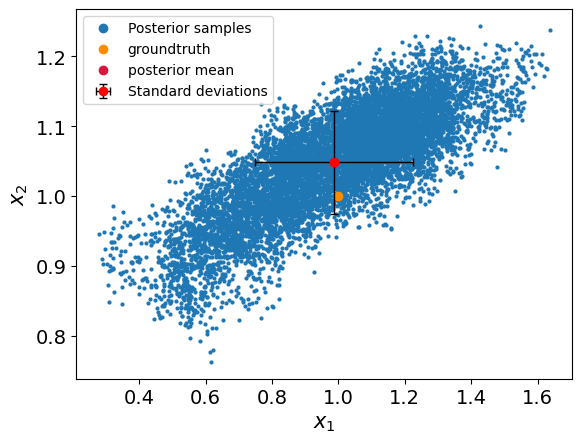

In [39]:
ax = plt.gca()
samples_warm.plot_pair(ax=ax)
ax.plot([], [], 'o', label='Posterior samples')
plt.plot(x[0], x[1], "o", color="darkorange", label="groundtruth")
plt.plot(samples_warm.mean()[0], samples_warm.mean()[1], 'o', color="crimson",
        label="posterior mean")
ax.errorbar(samples_warm.mean()[0], samples_warm.mean()[1], xerr=samples_warm.std()[0],
yerr=samples_warm.std()[1],fmt='o', color='red',ecolor='black', elinewidth=1,
capsize=3, label='Standard deviations', zorder=2)
#plt.plot(samples_warm.median()[0], samples_warm.median()[1], '+', color="darkorange", label="posterior median")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()

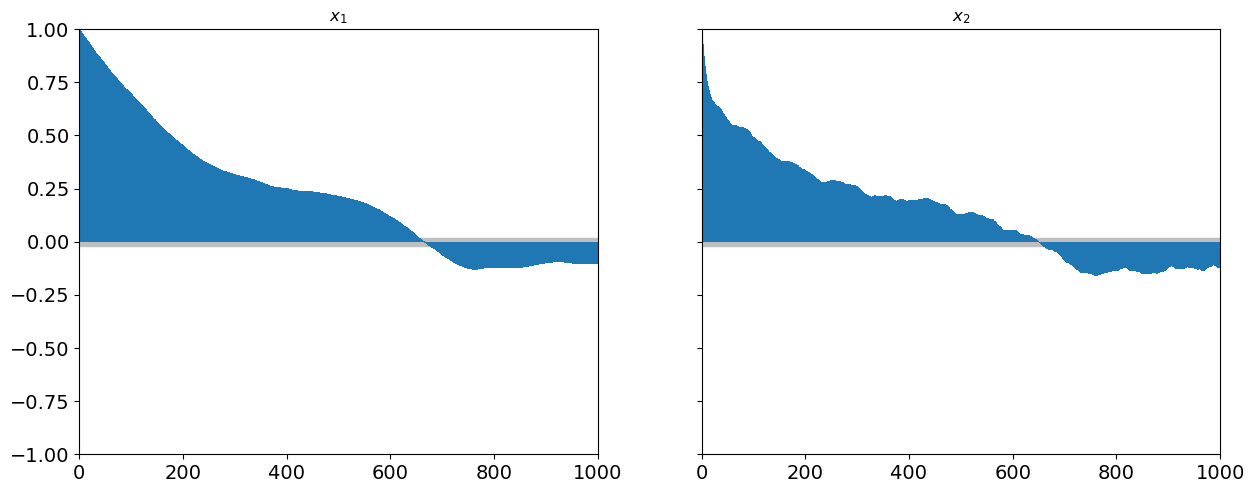

In [40]:
axes = samples_warm.plot_autocorrelation(max_lag=1000)
titles = [r'$x_1$', r'$x_2$']
for ax, title in zip(axes, titles):
    ax.set_title(title)

In [41]:
print(samples_warm.mean())
print(samples_warm.median())
print(samples_warm.std())

[0.9874305  1.04861883]
[1.01617711 1.05807751]
[0.23827109 0.07373431]


In [42]:
print(A(samples_warm.mean()))

3.786313829464101


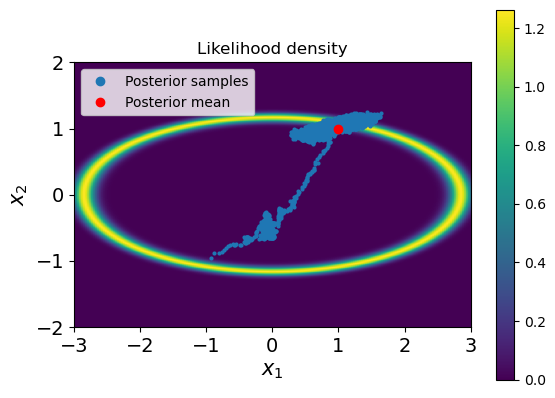

In [43]:
x1_lim = np.array([-3, 3])
x2_lim = np.array([-2, 2])
plot_2D_density(
    likelihood,
    v1_min=x1_lim[0], v1_max=x1_lim[1],
    v2_min=x2_lim[0], v2_max=x2_lim[1])
plt.colorbar()
plt.title("Likelihood density")

ax = plt.gca()
samples.plot_pair(ax=ax)
ax.plot([], [], 'o', label='Posterior samples')
plt.plot(samples_warm.mean()[0] , samples_warm.mean()[0], 'ro', label="Posterior mean")
plt.ylim(x2_lim);
plt.xlim(x1_lim);
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()